# Aplicações Práticas do Credit Risk+

## Seção 5 da Referência: Applications of Credit Risk+

Este notebook demonstra como usar o modelo Credit Risk+ em situações práticas de gestão de risco de crédito.

## 1. Visão Geral das Aplicações

O modelo pode ser usado para:

1. **Provisioning (Provisionamento de Risco)**
   - Calcular reservas para cobrir perdas esperadas e inesperadas
   - Atender requisitos regulatórios (Basileias)

2. **Limites de Crédito**
   - Determinar quanto crédito oferecer a cada contraparte
   - Baseado em risco, não apenas retorno

3. **Alocação de Capital Econômico**
   - Distribuir capital entre negócios/portfólios
   - Baseado em contribuição marginal de risco

4. **Gestão de Portfólio**
   - Identificar exposições concentradas
   - Otimizar mix de contrapartes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../creditriskplus')

from simple_model import calculate_loss_distribution_simple
from data import create_example_1a_portfolio

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Aplicação 1: Provisionamento de Risco (ACP e ICR)

**ACP (Annual Credit Provision)**: Provião anual para cobrir perdas esperadas
**ICR (Incremental Credit Reserve)**: Reserva incremental para perdas inesperadas

Fórmula (Eq. da Seção 5.2):
- ACP = E[Loss]
- ICR = VaR(99%) - E[Loss]
- Total Provision = ACP + ICR

In [2]:
# Carrega portfolio
portfolio = create_example_1a_portfolio()

# Calcula distribuição
A, el = calculate_loss_distribution_simple(
    exposures=portfolio['exposure'].values,
    mean_default_rates=portfolio['mean_default_rate'].values,
    std_default_rates=portfolio['std_default_rate'].values,
    recovery_rates=np.zeros(len(portfolio)),
    unit_size=10000,
    max_units=15000
)

# Calcula percentis para provision
cdf = np.cumsum(A)
unit_size = 10000

# Percentis de provision
confidence_levels = [90, 95, 99, 99.5]
provision_data = []

for conf in confidence_levels:
    idx = np.searchsorted(cdf, conf/100.0)
    var_loss = idx * unit_size
    icr = var_loss - el
    
    provision_data.append({
        'Confiança': f"{conf}%",
        'ACP ($)': f"${el:,.0f}",
        'ICR ($)': f"${icr:,.0f}",
        'Total ($)': f"${var_loss:,.0f}",
        'ICR/ACP': f"{icr/el:.2f}x"
    })

df_prov = pd.DataFrame(provision_data)
print("=== PROVISIONING: ACP E ICR ===")
print(df_prov.to_string(index=False))

print(f"\nInterpretação:")
print(f"- ACP cobre a perda esperada anualmente: ${el:,.0f}")
print(f"- ICR (99%) cobre eventos raros: ${(np.searchsorted(cdf, 0.99) * unit_size) - el:,.0f}")
print(f"- Razão: Eventos extremos são ~{((np.searchsorted(cdf, 0.99) * unit_size) - el)/el:.1f}x maiores que EL")

=== PROVISIONING: ACP E ICR ===
Confiança     ACP ($)     ICR ($)   Total ($) ICR/ACP
      90% $14,221,832 $17,198,168 $31,420,000   1.21x
      95% $14,221,832 $24,688,168 $38,910,000   1.74x
      99% $14,221,832 $41,028,168 $55,250,000   2.88x
    99.5% $14,221,832 $47,728,168 $61,950,000   3.36x

Interpretação:
- ACP cobre a perda esperada anualmente: $14,221,832
- ICR (99%) cobre eventos raros: $41,028,168
- Razão: Eventos extremos são ~2.9x maiores que EL


## 3. Aplicação 2: Limites de Crédito Baseados em Risco

Determine quanto crédito oferecer a cada contraparte baseado em seu risco individual.

In [3]:
# Calcula limite de crédito por contraparte
# Baseado em: máximo 1% do E[L] por contraparte

portfolio_with_limits = portfolio.copy()

# Expected loss por contraparte
portfolio_with_limits['el'] = (
    portfolio_with_limits['exposure'] *
    portfolio_with_limits['mean_default_rate']
)

# Limite sugerido: máximo 1.5% da perda esperada do portfólio
max_risk_appetite = el * 0.015
portfolio_with_limits['max_el_allowed'] = max_risk_appetite
portfolio_with_limits['max_exposure'] = (
    max_risk_appetite / portfolio_with_limits['mean_default_rate']
)
portfolio_with_limits['current_limit_ratio'] = (
    portfolio_with_limits['exposure'] /
    portfolio_with_limits['max_exposure']
)

# Ordena por concentração
limits_display = portfolio_with_limits.nlargest(10, 'current_limit_ratio')[[
    'obligor_id', 'exposure', 'mean_default_rate', 'max_exposure', 'current_limit_ratio'
]].copy()

limits_display.columns = ['Contraparte', 'Exposição ($)', 'Default Rate', 'Max Exposição ($)', 'Uso do Limite']
limits_display['Exposição ($)'] = limits_display['Exposição ($)'].apply(lambda x: f"${x:,.0f}")
limits_display['Max Exposição ($)'] = limits_display['Max Exposição ($)'].apply(lambda x: f"${x:,.0f}")
limits_display['Uso do Limite'] = limits_display['Uso do Limite'].apply(lambda x: f"{x:.1%}")

print("\n=== LIMITES DE CRÉDITO (TOP 10 CONCENTRAÇÕES) ===")
print(limits_display.to_string(index=False))

breaches = (portfolio_with_limits['current_limit_ratio'] > 1.0).sum()
print(f"\nContrapartes acima do limite: {breaches}")
if breaches > 0:
    print(f"Ação recomendada: Reduzir exposição em concentrações altas")


=== LIMITES DE CRÉDITO (TOP 10 CONCENTRAÇÕES) ===
 Contraparte Exposição ($)  Default Rate Max Exposição ($) Uso do Limite
          22    $6,480,322         0.300          $711,092        911.3%
          21    $6,466,533         0.300          $711,092        909.4%
          24   $15,410,906         0.100        $2,133,275        722.4%
          25   $20,238,895         0.075        $2,844,366        711.5%
          14    $4,928,989         0.300          $711,092        693.2%
           7    $2,652,184         0.300          $711,092        373.0%
          15    $5,042,312         0.100        $2,133,275        236.4%
           8    $2,957,685         0.150        $1,422,183        208.0%
          19    $5,764,596         0.075        $2,844,366        202.7%
          16    $5,320,364         0.075        $2,844,366        187.0%

Contrapartes acima do limite: 17
Ação recomendada: Reduzir exposição em concentrações altas


## 4. Aplicação 3: Análise de Stress

Como o portfólio reage a mudanças na taxa de default?

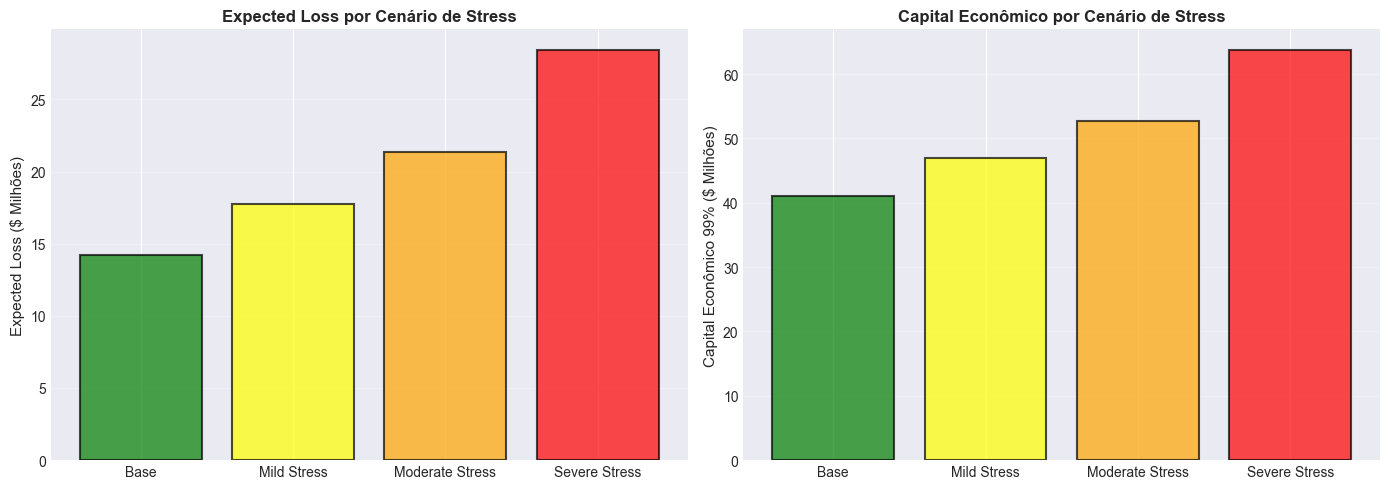


Interpretação:
- Em cenário de 50% de aumento nas taxas:
  E[Loss] sobe para $21,331,075
  Capital necessário sobe para $52,648,925
- Instituição deve estar preparada para cenários adversos


In [4]:
# Cenários de stress (multiplicador sobre as taxas de default)
stress_scenarios = {
    'base':            1.00,
    'mild_stress':     1.25,
    'moderate_stress': 1.50,
    'severe_stress':   2.00,
}

# Visualização de stress scenarios
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scenarios = list(stress_scenarios.keys())
els_by_scenario = []
caps_by_scenario = []

for scenario_name, factor in stress_scenarios.items():
    stressed_rates = portfolio['mean_default_rate'].values * factor
    stressed_std = portfolio['std_default_rate'].values * factor

    A_s, el_s = calculate_loss_distribution_simple(
        exposures=portfolio['exposure'].values,
        mean_default_rates=stressed_rates,
        std_default_rates=stressed_std,
        recovery_rates=np.zeros(len(portfolio)),
        unit_size=10000,
        max_units=15000
    )

    cdf_s = np.cumsum(A_s)
    idx_99_s = np.searchsorted(cdf_s, 0.99)
    var_99_s = idx_99_s * 10000
    cap_99_s = var_99_s - el_s

    els_by_scenario.append(el_s / 1e6)
    caps_by_scenario.append(cap_99_s / 1e6)

scenario_labels = [s.replace('_', ' ').title() for s in scenarios]

# E[Loss] por cenário
ax = axes[0]
colors_stress = ['green', 'yellow', 'orange', 'red']
ax.bar(scenario_labels, els_by_scenario, color=colors_stress, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Expected Loss ($ Milhões)', fontsize=11)
ax.set_title('Expected Loss por Cenário de Stress', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Capital Econômico por cenário
ax = axes[1]
ax.bar(scenario_labels, caps_by_scenario, color=colors_stress, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Capital Econômico 99% ($ Milhões)', fontsize=11)
ax.set_title('Capital Econômico por Cenário de Stress', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nInterpretação:")
print(f"- Em cenário de 50% de aumento nas taxas:")
print(f"  E[Loss] sobe para ${els_by_scenario[2]*1e6:,.0f}")
print(f"  Capital necessário sobe para ${caps_by_scenario[2]*1e6:,.0f}")
print(f"- Instituição deve estar preparada para cenários adversos")

## 5. Aplicação 4: Otimização de Portfólio

Use contribuições de risco para otimizar o mix de contrapartes.

In [5]:
# Calcula retorno por unidade de risco (baseado em EL)
portfolio_with_returns = portfolio.copy()

# Assume spreads de retorno por rating (simplificado)
spread_by_rating = {
    'A': 0.010,   # 100 bps
    'B': 0.016,   # 160 bps
    'C': 0.030,   # 300 bps
    'D': 0.050,   # 500 bps
    'E': 0.075,   # 750 bps
    'F': 0.100,   # 1000 bps
    'G': 0.150,   # 1500 bps
    'H': 0.300    # 3000 bps
}

portfolio_with_returns['spread'] = portfolio_with_returns['rating'].map(spread_by_rating)
portfolio_with_returns['annual_return'] = (
    portfolio_with_returns['exposure'] * 
    portfolio_with_returns['spread']
)
portfolio_with_returns['el_dollars'] = (
    portfolio_with_returns['exposure'] * 
    portfolio_with_returns['mean_default_rate']
)
portfolio_with_returns['return_per_risk'] = (
    portfolio_with_returns['annual_return'] / 
    portfolio_with_returns['el_dollars']
)

# Ordena por eficiência de retorno/risco
efficiency = portfolio_with_returns[[
    'obligor_id', 'rating', 'exposure', 'spread', 'mean_default_rate', 
    'annual_return', 'el_dollars', 'return_per_risk'
]].copy()

efficiency = efficiency.sort_values('return_per_risk', ascending=False)
efficiency_display = efficiency.head(10).copy()

efficiency_display['exposure'] = efficiency_display['exposure'].apply(lambda x: f"${x/1e6:.1f}M")
efficiency_display['spread'] = efficiency_display['spread'].apply(lambda x: f"{x:.1%}")
efficiency_display['mean_default_rate'] = efficiency_display['mean_default_rate'].apply(lambda x: f"{x:.1%}")
efficiency_display['annual_return'] = efficiency_display['annual_return'].apply(lambda x: f"${x/1000:.0f}K")
efficiency_display['el_dollars'] = efficiency_display['el_dollars'].apply(lambda x: f"${x/1000:.0f}K")
efficiency_display['return_per_risk'] = efficiency_display['return_per_risk'].apply(lambda x: f"{x:.2f}x")

print("\n=== EFICIÊNCIA DE RETORNO/RISCO (TOP 10) ===")
print(efficiency_display[['obligor_id', 'rating', 'spread', 'mean_default_rate', 'return_per_risk']].to_string(index=False))

print("\nRecomendação: Aumentar exposição em contrapartes com alta eficiência")
print("            Reduzir exposição em contrapartes com baixa eficiência")


=== EFICIÊNCIA DE RETORNO/RISCO (TOP 10) ===
 obligor_id rating spread mean_default_rate return_per_risk
          1      H  30.0%             30.0%           1.00x
         14      H  30.0%             30.0%           1.00x
         24      F  10.0%             10.0%           1.00x
         23      B   1.6%              1.6%           1.00x
         22      H  30.0%             30.0%           1.00x
         21      H  30.0%             30.0%           1.00x
         20      C   3.0%              3.0%           1.00x
         19      E   7.5%              7.5%           1.00x
         18      C   3.0%              3.0%           1.00x
         17      D   5.0%              5.0%           1.00x

Recomendação: Aumentar exposição em contrapartes com alta eficiência
            Reduzir exposição em contrapartes com baixa eficiência


## 6. Conclusão: Valor do Credit Risk+

O modelo fornece uma estrutura integrada para:

1. ✅ **Quantificar Risco**: Distribuição completa de perdas, não apenas EL
2. ✅ **Provisioning**: Determinar reservas necessárias (ACP/ICR)
3. ✅ **Limites**: Controlar concentração de forma metodológica
4. ✅ **Otimização**: Maximizar retorno por unidade de risco
5. ✅ **Stress Testing**: Avaliar robustez em cenários adversos

**Benefícios práticos:**
- Melhor alocação de capital
- Redução de surpresas de risco
- Conformidade regulatória (Basel, Solvência II)
- Melhor compreensão de trade-offs retorno/risco